# Syllabys

1. [Overview](#overview)
2. [Tensors and accelerated software](#tensors-and-accelerated-software)
3. [PyTorch data interfaces](#pytorch-data-interfaces)
4. [Model structure](#model-structure)
5. [Training process](#model-training)
6. [References and materials](#materials-and-usefull-links)

# Overview

<h3>Neural network workflow</h3>

![Neural network workflow](https://miro.medium.com/v2/resize:fit:1400/1*ZXAOUqmlyECgfVa81Sr6Ew.png)

Neural network principles:

1. Forward propagation:

    1. Input
    2. Hidden state
    3. Activation function
    4. Output

<br/>

2. Backward propagation:

    1. Loss function
    2. Optimization and weight update


Iterative repetition of forward and backward propagation to minimize loss function and get optimal weights.

<h3>NumPy-based neural network (example on logistic regression)</h3>



In [1]:
import numpy as np
from sklearn.datasets import make_classification

logistic_function = lambda x: 1 / (1 + np.exp(-x))

def compute_cost(theta, b, x, y):
    m = len(y)
    
    # Formula: z = Xw + b
    # x is (100, 4), theta is (4, 1) -> z is (100, 1)
    z = np.dot(x, theta) + b
    y_pred = logistic_function(z)
    
    # Cost (Binary Cross Entropy)
    # Adding a tiny epsilon (1e-15) prevents log(0) errors
    error = (y * np.log(y_pred + 1e-15)) + ((1 - y) * np.log(1 - y_pred + 1e-15))
    cost = -1 / m * np.sum(error)
    
    # Gradients
    # d_theta shape: (4, 100) dot (100, 1) = (4, 1)
    d_theta = 1 / m * np.dot(x.T, (y_pred - y))
    d_b = 1 / m * np.sum(y_pred - y)
    
    return cost, d_theta, d_b

def gradient_descent(x, y, theta, b, alpha, iterations):
    costs = []
    for i in range(iterations):
        cost, d_theta, d_b = compute_cost(theta, b, x, y)
        
        theta = theta - (alpha * d_theta)
        b = b - (alpha * d_b)
        
        costs.append(cost)
    return theta, b, costs

In [2]:
X, y = make_classification(
    n_features=4, n_redundant=0, n_informative=2, random_state=1, n_clusters_per_class=1
)
rng = np.random.RandomState(2)
X += 2 * rng.uniform(size=X.shape)
y = y.reshape(-1, 1)

# Initialize 4 weights and 1 bias
theta_init = np.random.randn(X.shape[1], 1) * 0.01
b_init = np.random.randn() * 0.1

# 1. Calculate and print the INITIAL cost
initial_cost, _, _ = compute_cost(theta_init, b_init, X, y)
print(f"Initial Cost (before training): {initial_cost:.6f}")
print(f"Initial Bias (b): {b_init:.4f}")
print("Initial Weights (W):\n", theta_init)
print("-" * 30)

# 2. Run training
theta_final, b_final, costs = gradient_descent(
    X, y, theta_init, b_init, alpha=0.1, iterations=1000
)

# 3. Print the FINAL results
print(f"Final Cost (after training):   {costs[-1]:.6f}")
print(f"Final Bias (b): {b_final:.4f}")
print("Final Weights (W):\n", theta_final)

Initial Cost (before training): 0.694465
Initial Bias (b): -0.0818
Initial Weights (W):
 [[ 4.24284998e-03]
 [-5.15786946e-05]
 [ 1.59540043e-02]
 [ 2.11291497e-03]]
------------------------------
Final Cost (after training):   0.109151
Final Bias (b): 1.8169
Final Weights (W):
 [[ 0.04519483]
 [-4.0918749 ]
 [ 0.73525229]
 [ 0.07886445]]


This is an implementation of the simplest one-layer model:

![Logistic regression schema](https://datahacker.rs/wp-content/uploads/2021/01/83-1024x579.jpg)

While in real life actual DNN architectures will use more complex architectures:

![More complex architectures](https://ascelibrary.org/cms/10.1061/(ASCE)ST.1943-541X.0003392/asset/176e59f6-aad9-4df8-9074-2b852e1155f0/assets/images/large/figure6.jpg)

<h2>DL frameworks are the tools that make DL processes less difficult</h2>

Frameworks offer:

- abstraction from the low-level operation with matrices and complex math operation 
- high-level programming interface and tools for building blocks to design, train, and validate deep neural networks
- parallelizing of the operation to accelerate processes
- automation of optimization and backpropagation


According to [Papers with code](https://paperswithcode.com/trends) among most implemented papers in Python at the moment there are next top-3 frameworks:


![Framework trends](supplementary_data/frameworks_usage_trends.png)

- PyTorch (60% of repositores with paper implementations)
- TensorFlow (3% of repositores with paper implementations)
- JAX (2% of repositores with paper implementations)


On Sep 2020, the top was:

- PyTorch (50%)
- TensorFlow (20%)
- JAX (0%)

# Tensors and accelerated software

`Tensors` are a specialized `data structure` that are very similar to arrays and matrices. In PyTorch, tensors are used to `encode the inputs and outputs of a model`, as well as the `model’s parameters`.

A tensor is the abstract version of nested lists of numbers. A 'vector' is a one-dimensional tensor. A 'matrix' is a two-dimensional tensor, and higher dimensions are referred to as 'n-dimensional tensors'.

Tensors are similar to NumPy’s ndarrays, except that tensors can `run on GPUs` or other hardware accelerators. 

In [3]:
%pip install torch Pillow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import torch
import numpy as np

In [5]:
# Initialize a Tensor

data = [[1, 2],[3, 4]]
x_data = torch.tensor(data)
print(x_data)

np_array = np.array(data)
x_np = torch.from_numpy(np_array)
print(x_np)

print(f"Shape of tensor: {x_data.shape}")
print(f"Datatype of tensor: {x_data.dtype}")
print(f"Device tensor is stored on: {x_data.device}")

print("NumPy data pointer:   ", np_array.__array_interface__['data'][0])
print("Torch tensor pointer: ", x_np.data_ptr())

tensor([[1, 2],
        [3, 4]])
tensor([[1, 2],
        [3, 4]])
Shape of tensor: torch.Size([2, 2])
Datatype of tensor: torch.int64
Device tensor is stored on: cpu
NumPy data pointer:    2296680588288
Torch tensor pointer:  2296680588288


Over 100 tensor operations, including arithmetic, linear algebra, matrix manipulation (transposing, indexing, slicing), sampling and more are comprehensively described [here](https://pytorch.org/docs/stable/torch.html) or more generally [here](https://pytorch.org/tutorials/beginner/basics/tensorqs_tutorial.html#operations-on-tensors).



<h3>CUDA</h3>

CUDA® is a parallel computing platform and programming model developed by NVIDIA for general computing on graphical processing units (GPUs). With CUDA, developers are able to dramatically speed up computing applications by harnessing the power of GPUs.


In GPU-accelerated applications, the sequential part of the workload runs on the CPU – which is optimized for single-threaded performance – while the compute intensive portion of the application runs on thousands of GPU cores in parallel. 

CUDA installation is available on [NVIDIA's official website](https://developer.nvidia.com/cuda-toolkit).


`torch.cuda` is used to set up and run CUDA operations. It keeps track of the currently selected GPU, and all CUDA tensors you allocate will by default be created on that device. The selected device can be changed with a `torch.cuda.device` context manager.

However, once a tensor is allocated, you can do operations on it irrespective of the selected device, and the results will be always placed on the same device as the tensor.



In [6]:
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

False
0
No GPU


In [7]:
# We move our tensor to the GPU if available
print("Address on CPU: ", x_data.data_ptr())

if torch.cuda.is_available():
    x_data = x_data.to("cuda")
    print(f"Device tensor is stored on: {x_data.device}")
print("Address after moving to GPU: ", x_data.data_ptr())

# or use:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
x_data = x_data.to(device)

# if more than one GPU is available, you can select the specific one (index starts from 0)
cuda0 = torch.device('cuda:0')

Address on CPU:  4593970905216
Address after moving to GPU:  4593970905216


Usage of the CUDA significantly speeds up models processes, such as training or inferencing.

# PyTorch data interfaces

Usually data is the first step to all ML tasks. It defines the model's input and output.

PyTorch provides two data primitives: `torch.utils.data.DataLoader` and `torch.utils.data.Dataset` that are designed to handle and manage data for training machine learning models and serve as high-level interface.

`Dataset` stores the samples and their corresponding labels, and `DataLoader` wraps an iterable around the `Dataset` to enable easy access to the samples.

PyTorch domain libraries provide a number of pre-loaded datasets and they could be used for prototyping DL models -  [Image Datasets](https://pytorch.org/vision/stable/datasets.html), [Text Datasets](https://pytorch.org/text/stable/datasets.html), and [Audio Datasets](https://pytorch.org/audio/stable/datasets.html).

In [8]:
# torchvision library to work with vision tasks (images, videos)
%pip install torchvision 
# torchaudio library to work with audio tasks - !pip install torchaudio

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Tabular datasets

Tabular data can be fully loaded into the memory and usually doesn't require some complex pre-processing.
So it simply can be loaded as Tensor objects without creation of interfaces.

In [9]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split


X, y = make_classification(
    n_features=4, n_redundant=0, n_informative=2, random_state=1, n_clusters_per_class=1, n_samples=10000
)

X, y = torch.from_numpy(X), torch.from_numpy(y)

X_train, X_test, y_train, y_test = train_test_split(X, y)
X_train.shape, X_test.shape

(torch.Size([7500, 4]), torch.Size([2500, 4]))

# Model Structure

Single neuron:

- takes some set of inputs
- generates a corresponding scalar output
- has a set of associated parameters that can be updated to optimize some objective function of interest


In more complex network where multiple outputs are needed, the more complex subject is used - `layer`, a collection of multiple neurons:

- take a set of inputs
- generate corresponding outputs
- are described by a set of tunable parameters


Neural network:

- complex of layers
- takes in raw inputs (the features)
- generates outputs (the predictions)
- possesses parameters (the combined parameters from all constituent layers)



To improve level of abstraction, the concept of `module` is introduced. 
A module could describe a single layer, a component consisting of multiple layers, or the entire model itself.

The PyTorch `nn` module is a core component facilitating the construction and training of neural networks. 
It provides a high-level abstraction for designing and implementing neural network architectures.

In [10]:
import torch
from torch import nn
import torch.nn.functional as F

In PyTorch `nn` module could be split into next groups:

- containers - Module, Sequential
- linear - Linear
- activations - non-linear units (ReLU, Sigmoid, LeakyReLU, Tanh, Softmax, etc.)
- normalizations - BatchNorm, LayerNorm, different variations
- loss functions - L1Loss, MSELoss, CrossEntropyLoss, etc.
- matrix layers (usually for CV tasks) - convolutional, pooling, padding, dropout
- sequential layers (usually for NLP tasks) - recurrent (RNN, LSTM, GRU), transformer (model, encoder, decoder), sparse


Every module in PyTorch subclasses the `nn.Module`. A neural network is a module itself that consists of other modules (layers). This nested structure allows for building and managing complex architectures easily.

Full list of possible modules is listed in [PyTorch nn documentation](https://pytorch.org/docs/stable/nn.html#).

In [11]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_1 = nn.Linear(28*28, 512)
        self.linear_2 = nn.Linear(512, 512)
        self.out_layer = nn.Linear(512, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.linear_1(x))
        x = F.relu(self.linear_2(x))
        
        return self.out_layer(x)

model = NeuralNetwork()

# Note that functional modules that are used in forward-propogation are not displayed here; 
# only modules from constructor are displayed
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_1): Linear(in_features=784, out_features=512, bias=True)
  (linear_2): Linear(in_features=512, out_features=512, bias=True)
  (out_layer): Linear(in_features=512, out_features=10, bias=True)
)


In cases similar to above where the output of previous layers go straight to the input of next layers without any additional processing - `Sequential` module could be used to design better network.

In [12]:
class NeuralNetwork_2(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits
    
model_2 = NeuralNetwork_2()
print(model_2)

NeuralNetwork_2(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


Some of modules could have alternative version with `Lazy` prefix in name.

Modules that lazily initialize parameters, or “lazy modules”, derive the shapes of their parameters from the first input(s) to their forward method. Until that first forward they contain `torch.nn.UninitializedParameter`'s that should not be accessed or used, and afterward they contain regular `torch.nn.Parameter`'s.

In [13]:
class NeuralNetwork_3(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.LazyLinear(512),
            nn.ReLU(),
            nn.LazyLinear(512),
            nn.ReLU(),
            nn.LazyLinear(10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits
    
model_3 = NeuralNetwork_3()
print(model_3)

NeuralNetwork_3(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): LazyLinear(in_features=0, out_features=512, bias=True)
    (1): ReLU()
    (2): LazyLinear(in_features=0, out_features=512, bias=True)
    (3): ReLU()
    (4): LazyLinear(in_features=0, out_features=10, bias=True)
  )
)


Classification models above return `logits` - the vector of raw (non-normalized) predictions that a classification model generates, which is ordinarily then passed to a normalization function. 

If the model is solving a multi-class classification problem, logits typically become an input to the `Softmax` function. The softmax function then generates a vector of (normalized) probabilities with one value for each possible class.

If only top class is needed from the output model - the normalization function could be swapped to `argmax` function.


Customary, `logits` are the final output of the model and it's normalization is performed outside model structure.

## Custom layers

In [14]:
# Layer without parameters; used to implement functional modules like activation functions, etc

class CenteredLayer(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, X):
        return X - X.mean()
    
layer = CenteredLayer()
layer(torch.tensor([1.0, 2, 3, 4, 5]))

tensor([-2., -1.,  0.,  1.,  2.])

In [15]:
net = nn.Sequential(nn.LazyLinear(128), CenteredLayer())
Y = net(torch.rand(4, 8))
Y.mean()

tensor(-1.8626e-09, grad_fn=<MeanBackward0>)

In [16]:
# Layer with parameters that could be learned during back-propagation
class MyLinear(nn.Module):
    def __init__(self, in_units, units):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(in_units, units))
        self.bias = nn.Parameter(torch.ones(units,))

    def forward(self, X):
        linear = torch.matmul(X, self.weight) + self.bias
        return F.relu(linear)
    
linear = MyLinear(5, 3)
linear.forward(torch.rand(2, 5))

tensor([[2.9472, 2.9472, 2.9472],
        [2.8997, 2.8997, 2.8997]], grad_fn=<ReluBackward0>)

In [17]:
linear(torch.rand(2, 5))

tensor([[2.4444, 2.4444, 2.4444],
        [2.6814, 2.6814, 2.6814]], grad_fn=<ReluBackward0>)

In [18]:
net = nn.Sequential(MyLinear(64, 8), MyLinear(8, 1))
net(torch.rand(2, 64))

tensor([[282.1169],
        [257.7538]], grad_fn=<ReluBackward0>)

More about disabling could be read on [PyTorch auto-grad documentation](https://pytorch.org/docs/stable/notes/autograd.html#locally-disabling-gradient-computation).

`Note:` After loading saved model, `model.eval()` method is called to set specifics layers (such as, Dropout, Normalization, etc.) to inference mode

##here

# Materials and usefull links

1. [PyTorch Basics tytorial](https://pytorch.org/tutorials/beginner/basics/intro.html)
2. [PyTorch Data Interfaces](https://pytorch.org/docs/stable/data.html)
3. [D2L Builders' Guide](https://d2l.ai/chapter_builders-guide/index.html)
4. [PyTorch Auto-differentiation basics](https://pytorch.org/tutorials/beginner/basics/autogradqs_tutorial.html)
5. [PyTorch Auto-differentiation intro](https://pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html#)
6. [PyTorch Auto-differentiation mechanics](https://pytorch.org/docs/stable/notes/autograd.html#)
7. [D2L Propogation and graphs](https://d2l.ai/chapter_multilayer-perceptrons/backprop.html)
8. [Understanding PyTorch graphs and autograd](https://blog.paperspace.com/pytorch-101-understanding-graphs-and-automatic-differentiation/)
9. [PyTorch Optimization](https://pytorch.org/tutorials/beginner/basics/optimization_tutorial.html)
10. Grokking Deep Learning by Andrew W. Trask
11. [PyTorch models visualization](https://pytorch.org/tutorials/intermediate/tensorboard_tutorial.html)

Tools:

1. [PyTorch Lightning](https://lightning.ai/pytorch-lightning) - tool upon PyTorch to make training and model designing easier
2. [Netron](https://netron.app/) - tool for visualizing the model architecture
3. [PyTorch eco-system](https://pytorch.org/ecosystem/) - list of PyTorch tools
4. [WandB](https://github.com/wandb/wandb) - tools for experementation tracking and its visualization


In [19]:
print("Initial Weights (W):\n")
# print console output of the initial weights and bias here



Initial Weights (W):



# Homework

1. Train NN model with custom linear architecture on A-Z Handwritten Alphabet dataset from Kaggle (image data with resolution not higher than 80x80 pixels - 
[A-Z Handwritten Alphabet](https://www.kaggle.com/datasets/sachinpatel21/az-handwritten-alphabets-in-csv-format), etc.)
2. Visualize epoch progress (loss and accuracy curves) *both train and test
3. Visualize 10 random elements from test set and model results for those elements

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

# We only open a portion of the dataset to avoid overloading memory. Because the full dataset has 372452 rows, we analys 1.3 minutes.
df = pd.read_csv(
    "A_Z Handwritten Data.csv", 
    header=None, 
    nrows=370000 # x/372452
)

print("Розмір датасету:", df.shape)
print("Перші рядки:")
df.head()

letters = df[0].unique()
print("Unique letters in the dataset:", letters)

Розмір датасету: (370000, 785)
Перші рядки:
Unique letters in the dataset: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25]


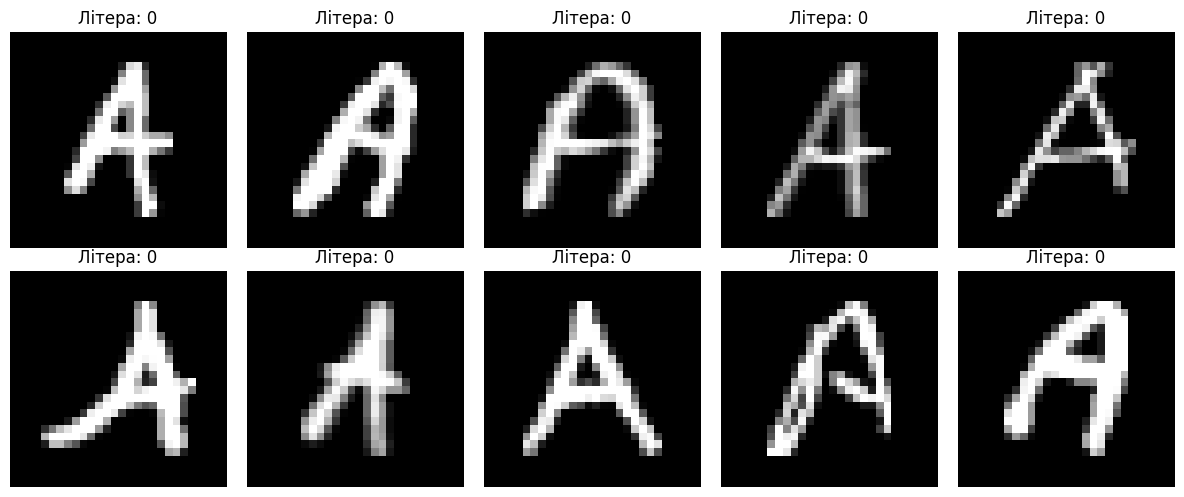

In [21]:
# Visualization of several examples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    pixels = df.iloc[i, 1:].values.reshape(28, 28)
    label  = df.iloc[i, 0]
    ax.imshow(pixels, cmap='gray')
    ax.set_title(f"Літера: {letters[int(label)]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import gc

# Resolution of symptoms 
X = df.iloc[:, 1:].values.astype(np.float32) / 255.0
y = df.iloc[:, 0].values.astype(np.int64)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train)
y_train_tensor = torch.tensor(y_train)
X_test_tensor = torch.tensor(X_test)
y_test_tensor = torch.tensor(y_test)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Creating DataLoaders for batch processing
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# out of memory error, so we delete the original variables and call garbage collector
del X, y, X_train, y_train, X_test, y_test
gc.collect()

print(f"Тренувальних зразків: {len(train_dataset)}")
print(f"Тестових зразків: {len(test_dataset)}")

Тренувальних зразків: 296000
Тестових зразків: 74000


In [23]:
import torch.nn as nn
import torch.nn.functional as F

class CustomLinearNN(nn.Module):
    def __init__(self, num_classes=26):
        super(CustomLinearNN, self).__init__()
        # Input layer: a 28x28 image is converted to a 784-pixel vector
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        # Output layer has 26 neurons (one for each letter)
        self.fc3 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CustomLinearNN(num_classes=26).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(f"Модель працюватиме на: {device}")
print(model)

Модель працюватиме на: cpu
CustomLinearNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=26, bias=True)
)


In [24]:
epochs = 10
train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

for epoch in range(epochs):
    # --- TRAINING ---
    model.train()
    running_loss = 0.0
    correct_train, total_train = 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # Очищаємо градієнти
        outputs = model(inputs) # Пряме поширення (Forward pass)
        loss = criterion(outputs, labels) # Обчислення помилки
        loss.backward() # Зворотне поширення (Backward pass)
        optimizer.step() # Оновлення ваг

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # --- VALIDATION ---
    model.eval()
    running_val_loss = 0.0
    correct_val, total_val = 0, 0

    with torch.no_grad(): # Disable gradient calculations for testing
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_test_loss = running_val_loss / total_val
    epoch_test_acc = correct_val / total_val
    test_losses.append(epoch_test_loss)
    test_accuracies.append(epoch_test_acc)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.4f} | "
          f"Test Loss: {epoch_test_loss:.4f}, Acc: {epoch_test_acc:.4f}")

Epoch [1/10] | Train Loss: 0.3303, Acc: 0.9086 | Test Loss: 0.1541, Acc: 0.9567
Epoch [2/10] | Train Loss: 0.1159, Acc: 0.9671 | Test Loss: 0.0989, Acc: 0.9726
Epoch [3/10] | Train Loss: 0.0827, Acc: 0.9761 | Test Loss: 0.0823, Acc: 0.9764
Epoch [4/10] | Train Loss: 0.0638, Acc: 0.9815 | Test Loss: 0.0758, Acc: 0.9790
Epoch [5/10] | Train Loss: 0.0509, Acc: 0.9846 | Test Loss: 0.0666, Acc: 0.9814
Epoch [6/10] | Train Loss: 0.0425, Acc: 0.9870 | Test Loss: 0.0607, Acc: 0.9836
Epoch [7/10] | Train Loss: 0.0353, Acc: 0.9892 | Test Loss: 0.0567, Acc: 0.9842
Epoch [8/10] | Train Loss: 0.0300, Acc: 0.9905 | Test Loss: 0.0533, Acc: 0.9858
Epoch [9/10] | Train Loss: 0.0256, Acc: 0.9918 | Test Loss: 0.0611, Acc: 0.9837
Epoch [10/10] | Train Loss: 0.0228, Acc: 0.9925 | Test Loss: 0.0563, Acc: 0.9852


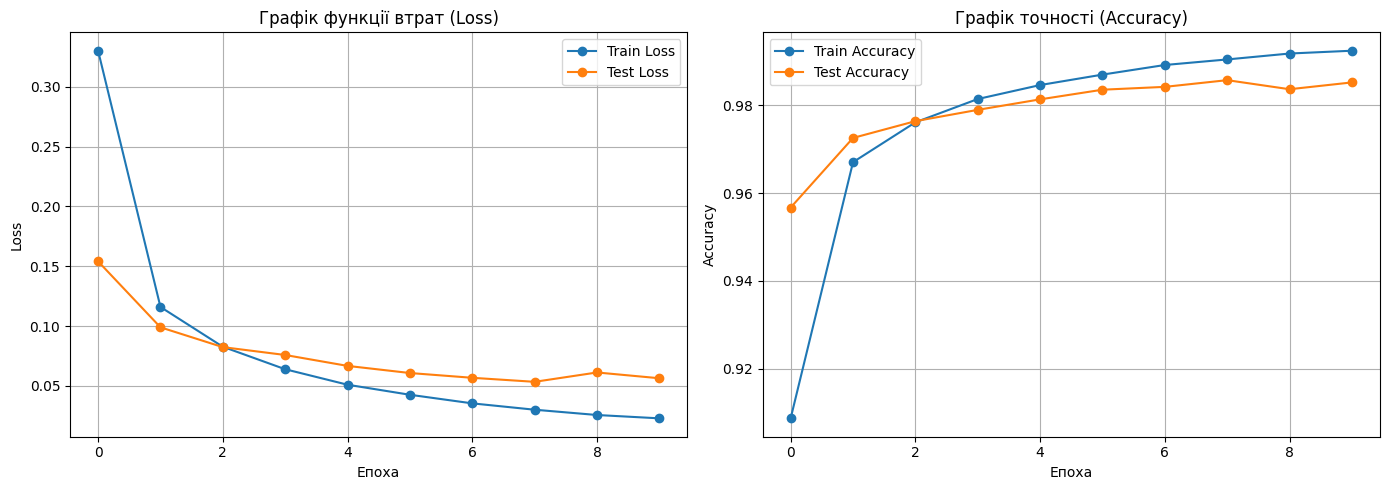

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss Chart
ax1.plot(train_losses, label='Train Loss', marker='o')
ax1.plot(test_losses, label='Test Loss', marker='o')
ax1.set_title('Графік функції втрат (Loss)')
ax1.set_xlabel('Епоха')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Chart Accuracy
ax2.plot(train_accuracies, label='Train Accuracy', marker='o')
ax2.plot(test_accuracies, label='Test Accuracy', marker='o')
ax2.set_title('Графік точності (Accuracy)')
ax2.set_xlabel('Епоха')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

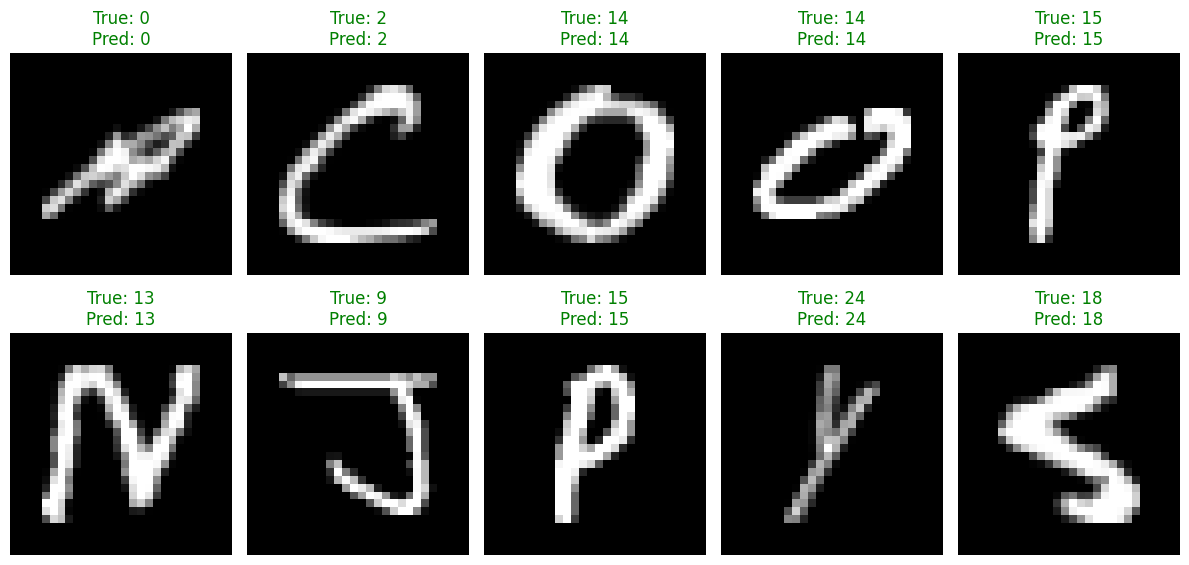

In [26]:
import random

model.eval()
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
 
random_indices = random.sample(
    range(len(test_dataset)),
    10
)

with torch.no_grad():
    for i, ax in enumerate(axes.flat):
        idx = random_indices[i]
        image_tensor, label_tensor = test_dataset[idx]

        # Add the batch size (1,784) and transfer it to the device
        input_data = image_tensor.unsqueeze(0).to(device) 
        output = model(input_data)
        
        _, predicted_class = torch.max(output, 1)

        img_plot = image_tensor.numpy().reshape(28, 28)
        true_letter = letters[label_tensor.item()]
        pred_letter = letters[predicted_class.item()]

        ax.imshow(img_plot, cmap='gray')
        
        color = 'green' if true_letter == pred_letter else 'red'
        ax.set_title(f"True: {true_letter}\nPred: {pred_letter}", color=color)
        ax.axis('off')

plt.tight_layout()
plt.show()